1. Import Libraries

Import TensorFlow/Keras, HuggingFace Datasets, and evaluation tools.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import load_dataset

c:\Users\Pritesh\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2. Load Dataset

Load the dair-ai/emotion dataset from Hugging Face. https://huggingface.co/datasets/dair-ai/emotion

In [2]:
emotion_dataset = load_dataset("dair-ai/emotion")

In [3]:
train_text      = emotion_dataset['train']['text']
train_label     = emotion_dataset['train']['label']

test_text       = emotion_dataset['test']['text']
test_label      = emotion_dataset['test']['label']

In [4]:
label_names = emotion_dataset['train'].features['label'].names

In [5]:
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [6]:
train_label

Column([0, 0, 3, 2, 3, ...])

In [7]:
df_train = pd.DataFrame(
    {
        'text'  : train_text,
        'label' : [label_names[i] for i in train_label]
    }
)

df_test = pd.DataFrame(
    {
        'text'  : test_text,
        'label' : [label_names[i] for i in test_label]
    }
)

In [8]:
df_train.isnull().sum()

text     0
label    0
dtype: int64

In [9]:
df_test.isnull().sum()

text     0
label    0
dtype: int64

In [10]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


3. Exploratory Data Analysis (EDA)

Visualize class distribution across the 6 emotion labels.



In [11]:
df_train['label'].value_counts().index

Index(['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'], dtype='str', name='label')

<Axes: xlabel='label', ylabel='count'>

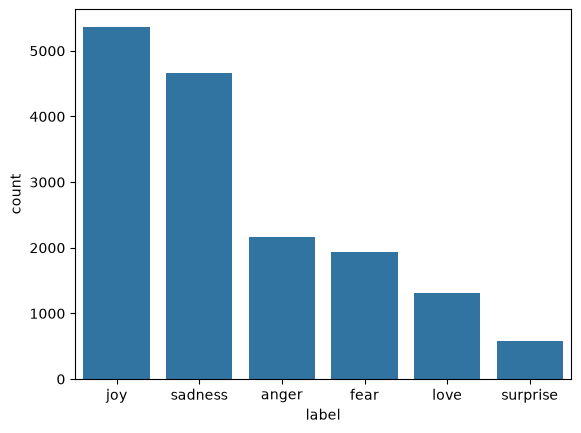

In [12]:
sns.countplot(x="label",data = df_train , order = df_train["label"].value_counts().index)


4. Data Preprocessing - Using NLP
   

Tokenize text, pad sequences to max length 50, and convert labels to NumPy arrays.

In [13]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000
tokenizer = Tokenizer(num_words=max_words, oov_token='')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequenece = tokenizer.texts_to_sequences(df_test['text'])

max_length = max(len(seq) for seq in train_sequence)
padded_train_sequence = pad_sequences(train_sequence,maxlen=max_length,padding='post', truncating='post')
padded_test_sequence = pad_sequences(test_sequenece ,maxlen=max_length,padding='post', truncating='post')

train_labels = np.array(train_label)
test_labels  = np.array(test_label)

num_classes = len(np.unique(train_labels))
num_classes

print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Max Sentence Length: {padded_train_sequence.shape[1]}")

Vocabulary Size: 15213
Max Sentence Length: 66


5. Shared Training Utilities

Compute balanced class weights to handle dataset skew and setup early stopping.

In [14]:
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(
    class_weight = "balanced",
    classes = np.unique(train_labels),
    y = train_labels
)

class_weight_dict = dict(enumerate(class_weights))

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

6. Phase 1 — Plain Foundational Models

Train plain (non-bidirectional) Simple RNN, Standard LSTM, and Standard GRU models.|

6.1 Model 1 — Simple RNN

Plain unrolled Recurrent Neural Network.

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
     

In [ ]:

rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)





Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 59s 89ms/step - accuracy: 0.1589 - loss: 2.0660 - val_accuracy: 0.1375 - val_loss: 1.7690
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - accuracy: 0.1446 - loss: 1.8946 - val_accuracy: 0.1375 - val_loss: 1.7591
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 55s 109ms/step - accuracy: 0.1353 - loss: 1.8285 - val_accuracy: 0.1400 - val_loss: 1.7778
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 97s 138ms/step - accuracy: 0.1370 - loss: 1.8093 - val_accuracy: 0.2890 - val_loss: 1.7601
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 62s 99ms/step - accuracy: 0.1492 - loss: 1.8034 - val_accuracy: 0.0790 - val_loss: 1.7804


6.2 Model 2 — Standard LSTM


Plain stacked Long Short-Term Memory network.

In [ ]:
lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)



c:\Users\Pritesh\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 80s 137ms/step - accuracy: 0.1560 - loss: 1.7947 - val_accuracy: 0.1375 - val_loss: 1.7798
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 67s 134ms/step - accuracy: 0.1406 - loss: 1.7939 - val_accuracy: 0.1375 - val_loss: 1.7869
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 57s 114ms/step - accuracy: 0.1694 - loss: 1.7936 - val_accuracy: 0.3475 - val_loss: 1.7770
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 66s 132ms/step - accuracy: 0.1789 - loss: 1.7941 - val_accuracy: 0.1115 - val_loss: 1.7923
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 68s 136ms/step - accuracy: 0.1471 - loss: 1.7931 - val_accuracy: 0.3465 - val_loss: 1.7848
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 84ms/step - accuracy: 0.1564 - loss: 1.7930 - val_accuracy: 0.0795 - val_loss: 1.7982


6.3 Model 3 — Standard GRU

Plain stacked Gated Recurrent Unit network.

In [33]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)



Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 133ms/step - accuracy: 0.1656 - loss: 1.7965 - val_accuracy: 0.3475 - val_loss: 1.7867
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 64s 129ms/step - accuracy: 0.1436 - loss: 1.7954 - val_accuracy: 0.2905 - val_loss: 1.7744
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 60s 120ms/step - accuracy: 0.1488 - loss: 1.7945 - val_accuracy: 0.2905 - val_loss: 1.7653
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 69s 137ms/step - accuracy: 0.1726 - loss: 1.7945 - val_accuracy: 0.0330 - val_loss: 1.8008
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 75s 122ms/step - accuracy: 0.1637 - loss: 1.7940 - val_accuracy: 0.0795 - val_loss: 1.8035
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 67s 133ms/step - accuracy: 0.1421 - loss: 1.7940 - val_accuracy: 0.3475 - val_loss: 1.7607
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 73s 146ms/step - accuracy: 0.1501 - loss: 1.7943 - val_accuracy: 0.0795 - val_loss: 1.7980
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 65s 131ms/step - accuracy: 0.1376 - loss: 1

6.4 Phase 1 Ranking & Selection

Rank foundational models to pick the best base cell for Phase 2.

In [34]:
rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)




result_df = pd.DataFrame({
    'Model' : ['RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
    }).sort_values(by='Test Accuracy',ascending=False)
result_df

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.1375 - loss: 1.7591
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.3475 - loss: 1.7770
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.3475 - loss: 1.7607


,Model,Test Loss,Test Accuracy
1,LSTM,1.777020,0.3475
2,GRU,1.760654,0.3475
0,RNN,1.759104,0.1375


7. Phase 2 — Advanced Bidirectional GRU

Enhance GRU with Bidirectional layers, 300D embeddings, and 0.5 dropout regularization.


7.1 Model 4 — Advanced Stacked Bidirectional GRU

In [35]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300 , input_length = 50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') #Output Layer
    
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

c:\Users\Pritesh\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Train & Evaluate Advanced Bidirectional GRU

In [36]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)
     

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 165s 281ms/step - accuracy: 0.5857 - loss: 0.9882 - val_accuracy: 0.8920 - val_loss: 0.3478
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 118s 235ms/step - accuracy: 0.9174 - loss: 0.2424 - val_accuracy: 0.9155 - val_loss: 0.2344
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 87s 174ms/step - accuracy: 0.9424 - loss: 0.1569 - val_accuracy: 0.9090 - val_loss: 0.2804
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 104s 209ms/step - accuracy: 0.9559 - loss: 0.1219 - val_accuracy: 0.9090 - val_loss: 0.3236
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 86s 171ms/step - accuracy: 0.9696 - loss: 0.0862 - val_accuracy: 0.9135 - val_loss: 0.3005


In [37]:


BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")
     

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.9155 - loss: 0.2344
BiGRU Loss: 0.23442792892456055
BiGRU Accuracy: 0.9154999852180481


8. Overall Evaluation & Bias Analysis

Consolidate test metrics, plot raw & normalized confusion matrices, and analyze bias.

8.1 Final Model Confusion Matrices (Raw Counts & Normalized %)

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step


<Axes: >

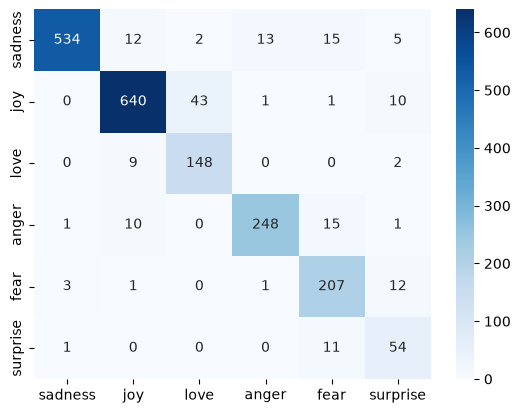

In [40]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence),axis=1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions),annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
#
     

9. Final Predictions

Test the winning model on unseen sample sentences.



In [42]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')
     

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: fear
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise



10. Save Model & Tokenizer

Export trained model and tokenizer artifacts for API deployment.

In [46]:
import os
import pickle

model_dir = "Artifacts"
os.makedirs(model_dir,exist_ok=True)

BiGRU.save(os.path.join(model_dir,"BiGRU_model.keras"))

with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)